In [1]:
!pip install -q pandas numpy scikit-learn networkx matplotlib pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 68.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. SYNTHETIC DISSECTED TELEMETRY GENERATOR
# Mirrors fields extracted from PCAP/Zeek: SIP, DNS, GTP, TCP/IP
# ---------------------------------------------------------
def generate_dissected_traffic_stream(n_records=3000, seed=42):
    np.random.seed(seed)
    base_time = datetime(2026, 9, 9, 0, 0, 0)

    # 50 simulated baseline actors + 3 covert threat actors
    normal_actors = [f"ENTITY_{i:02d}" for i in range(1, 51)]
    threat_actors = ["ENTITY_97", "ENTITY_98", "ENTITY_99"]
    all_actors = normal_actors + threat_actors

    records = []
    for _ in range(n_records):
        # 90% normal traffic, 10% covert target activity
        is_threat = np.random.rand() < 0.10
        actor = np.random.choice(threat_actors) if is_threat else np.random.choice(normal_actors)

        # Timestamp distribution (threats prefer late-night 01:00-04:00 UTC)
        if is_threat:
            hour_offset = np.random.choice([1, 2, 3, 23])
            minute_offset = np.random.randint(0, 60)
            record_time = base_time + timedelta(hours=int(hour_offset), minutes=int(minute_offset))
            proto = np.random.choice(["SIP", "GTP-U", "DNS_TUNNEL"], p=[0.4, 0.4, 0.2])
            ip = f"198.51.100.{np.random.randint(1, 254)}"  # High IP churn (VPN/Proxy)
            dest_port = np.random.choice([5060, 2152, 53, 8443])
            bytes_out = np.random.randint(5000, 80000)
            duration = np.random.uniform(0.1, 1.5)
            domain = np.random.choice(["auth-staging-v3.org", "c2-sync-gate.top", "edge-telemetry.io"])
            sip_call_id = f"call-{np.random.randint(100, 999)}@voip.host" if proto == "SIP" else None
            cell_tower = np.random.choice(["TOWER_ALPHA", "TOWER_BETA"])
        else:
            record_time = base_time + timedelta(hours=np.random.randint(8, 20), minutes=np.random.randint(0, 60))
            proto = np.random.choice(["TCP_HTTP", "TLS_HTTPS", "DNS"], p=[0.3, 0.5, 0.2])
            ip = f"10.0.1.{int(actor.split('_')[1])}"  # Stable IP assignment
            dest_port = np.random.choice([80, 443, 53])
            bytes_out = np.random.randint(200, 4000)
            duration = np.random.uniform(1.0, 30.0)
            domain = np.random.choice(["google.com", "microsoft.com", "aws.amazon.com", "github.com"])
            sip_call_id = None
            cell_tower = "TOWER_CORP_HQ"

        records.append({
            "timestamp": record_time,
            "actor_id": actor,
            "source_ip": ip,
            "protocol": proto,
            "destination_port": dest_port,
            "bytes_transferred": bytes_out,
            "duration_sec": duration,
            "domain_queried": domain,
            "sip_call_id": sip_call_id,
            "cell_tower": cell_tower
        })

    df = pd.DataFrame(records)
    return df.sort_values("timestamp").reset_index(drop=True)

raw_telemetry = generate_dissected_traffic_stream()
print(f"[*] Ingested {len(raw_telemetry)} raw dissected events across {raw_telemetry['actor_id'].nunique()} entities.")

[*] Ingested 3000 raw dissected events across 53 entities.


In [3]:
# ---------------------------------------------------------
# 2. BEHAVIORAL PROFILE AGGREGATOR
# Aggregates raw packet/session records into continuous behavioral metrics
# ---------------------------------------------------------
def create_entity_behavioral_profiles(df):
    profiles = []

    for actor, group in df.groupby("actor_id"):
        # 1. Temporal metrics
        hours = group["timestamp"].dt.hour
        night_activity_ratio = np.mean((hours >= 1) & (hours <= 4))

        # 2. Infrastructure & Volatility metrics
        unique_ips = group["source_ip"].nunique()
        ip_churn_ratio = unique_ips / len(group)

        # 3. Protocol & Tunneling Diversity
        protocols = group["protocol"].value_counts(normalize=True)
        tunnel_ratio = protocols.get("GTP-U", 0.0) + protocols.get("DNS_TUNNEL", 0.0)
        sip_presence = 1.0 if "SIP" in protocols else 0.0

        # 4. Volumetric & Traffic stats
        total_volume = group["bytes_transferred"].sum()
        mean_duration = group["duration_sec"].mean()

        # 5. External domain diversity
        unique_domains = group["domain_queried"].nunique()

        profiles.append({
            "actor_id": actor,
            "night_activity_ratio": night_activity_ratio,
            "ip_churn_ratio": ip_churn_ratio,
            "tunneling_protocol_ratio": tunnel_ratio,
            "sip_signaling_flag": sip_presence,
            "total_bytes": total_volume,
            "avg_session_duration": mean_duration,
            "unique_domains": unique_domains,
            "total_events": len(group)
        })

    return pd.DataFrame(profiles)

entity_profiles = create_entity_behavioral_profiles(raw_telemetry)
entity_profiles.head()

,actor_id,night_activity_ratio,ip_churn_ratio,tunneling_protocol_ratio,sip_signaling_flag,total_bytes,avg_session_duration,unique_domains,total_events
0,ENTITY_01,0.0,0.021277,0.0,0.0,100525,17.153246,4,47
1,ENTITY_02,0.0,0.018519,0.0,0.0,118453,17.233949,4,54
2,ENTITY_03,0.0,0.021739,0.0,0.0,89012,14.272540,4,46
3,ENTITY_04,0.0,0.020408,0.0,0.0,95557,15.303863,4,49
4,ENTITY_05,0.0,0.017241,0.0,0.0,111863,15.373176,4,58


In [4]:
# ---------------------------------------------------------
# 3. ANOMALY DETECTION ENGINE FOR TARGET IDENTIFICATION
# Uses Isolation Forest on non-linear behavioral profiles
# ---------------------------------------------------------
feature_cols = [
    "night_activity_ratio", "ip_churn_ratio", "tunneling_protocol_ratio",
    "sip_signaling_flag", "total_bytes", "avg_session_duration", "unique_domains"
]

X = entity_profiles[feature_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest: Flags top 6% behavioral outliers as new targets
iso_forest = IsolationForest(contamination=0.06, random_state=42)
entity_profiles["anomaly_flag"] = iso_forest.fit_predict(X_scaled)  # -1 for outliers, 1 for inliers

# Calibrated Risk Score: Map decision function to [0, 1] range
decision_scores = iso_forest.decision_function(X_scaled)
entity_profiles["target_risk_score"] = 1.0 - (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())

# Rank Identified Targets
new_targets = entity_profiles[entity_profiles["anomaly_flag"] == -1].sort_values("target_risk_score", ascending=False)
print("\n" + "="*70)
print("             PRIORITIZED TARGET IDENTIFICATION QUEUE")
print("="*70)
print(new_targets[["actor_id", "target_risk_score", "ip_churn_ratio", "night_activity_ratio", "tunneling_protocol_ratio"]])


             PRIORITIZED TARGET IDENTIFICATION QUEUE
     actor_id  target_risk_score  ip_churn_ratio  night_activity_ratio  \
52  ENTITY_99           1.000000        0.790909              0.827273   
51  ENTITY_98           0.996162        0.884615              0.721154   
50  ENTITY_97           0.978986        0.842105              0.778947   
47  ENTITY_48           0.546026        0.025000              0.000000   

    tunneling_protocol_ratio  
52                  0.609091  
51                  0.663462  
50                  0.547368  
47                  0.000000  


[*] Built Knowledge Graph: 196 Nodes, 1047 Edges


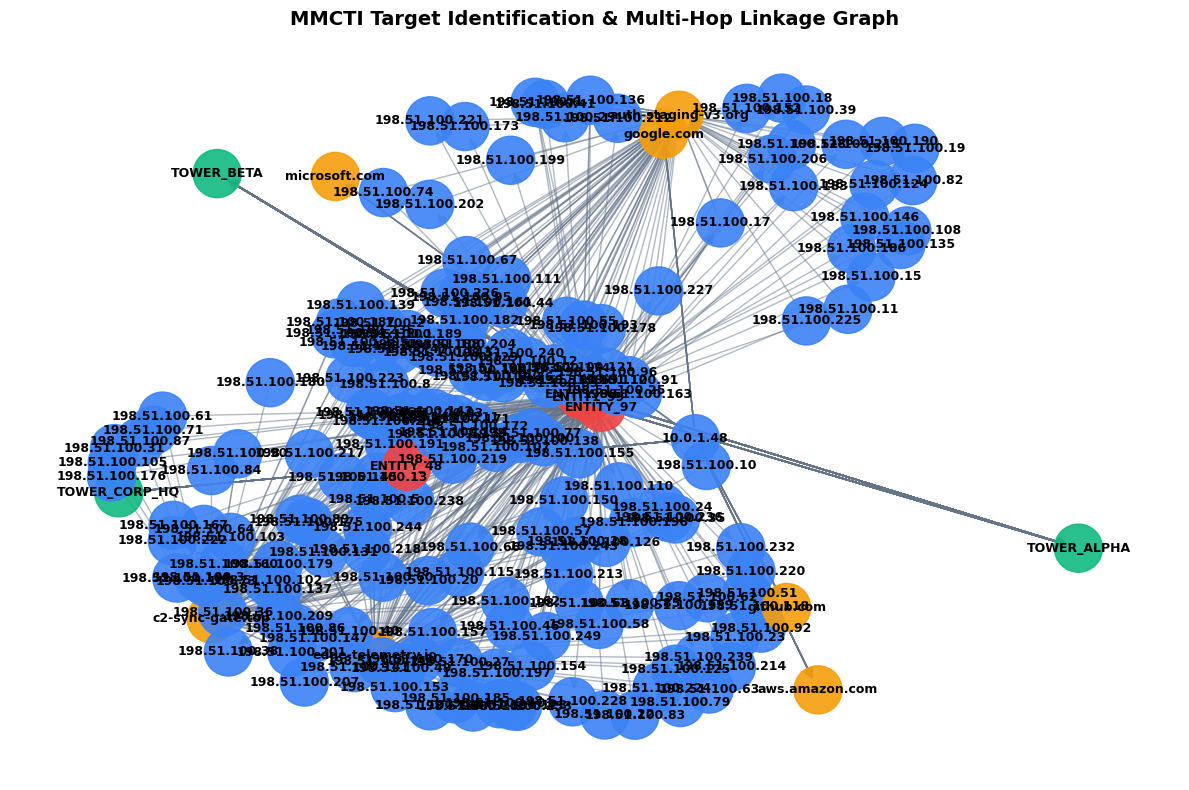

In [5]:
# ---------------------------------------------------------
# 4. GRAPH ENTITY RESOLUTION & LINKAGE (NetworkX)
# Materializes identified targets into a multi-hop knowledge graph
# ---------------------------------------------------------
G = nx.MultiDiGraph()

# Build Graph from Dissected Telemetry for identified high-risk targets
flagged_target_ids = set(new_targets["actor_id"])

for _, row in raw_telemetry.iterrows():
    actor = row["actor_id"]
    if actor not in flagged_target_ids:
        continue  # Keep graph focused on suspect clusters

    ip = row["source_ip"]
    domain = row["domain_queried"]
    tower = row["cell_tower"]
    proto = row["protocol"]

    # 1. Add Target Node
    risk = new_targets.loc[new_targets["actor_id"] == actor, "target_risk_score"].values[0]
    G.add_node(actor, type="Actor", risk=float(risk), color="#ef4444")

    # 2. Add Infrastructure Nodes
    G.add_node(ip, type="IP_Infrastructure", color="#3b82f6")
    G.add_node(domain, type="Staging_Domain", color="#f59e0b")
    G.add_node(tower, type="Cell_Tower", color="#10b981")

    # 3. Add Directed Labeled Relationships
    G.add_edge(actor, ip, relationship="ROUTED_THROUGH", protocol=proto)
    G.add_edge(ip, domain, relationship="RESOLVES_TO")
    G.add_edge(actor, tower, relationship="CO_LOCATED_AT")

print(f"[*] Built Knowledge Graph: {G.number_of_nodes()} Nodes, {G.number_of_edges()} Edges")

# ---------------------------------------------------------
# 5. VISUALIZATION IN GOOGLE COLAB
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.35, seed=42)

node_colors = [data["color"] for _, data in G.nodes(data=True)]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1200, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color="#64748b", alpha=0.5, arrows=True, arrowsize=15)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

plt.title("MMCTI Target Identification & Multi-Hop Linkage Graph", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# ---------------------------------------------------------
# 6. EXPORT CYPHER QUERIES FOR NEO4J MIGRATION
# Converts discovered linkages into ready-to-run Neo4j Cypher code
# ---------------------------------------------------------
print("\n" + "="*70)
print("             GENERATED NEO4J CYPHER INGESTION STATEMENTS")
print("="*70)

cypher_statements = []
for node, data in G.nodes(data=True):
    lbl = data.get("type", "Entity")
    if lbl == "Actor":
        cypher_statements.append(f"MERGE (n:{lbl} {{id: '{node}', risk: {data['risk']:.2f}}});")
    else:
        cypher_statements.append(f"MERGE (n:{lbl} {{id: '{node}'}});")

for u, v, data in G.edges(data=True):
    rel = data.get("relationship", "CONNECTED_TO")
    cypher_statements.append(f"MATCH (a {{id: '{u}'}}), (b {{id: '{v}'}}) MERGE (a)-[:{rel}]->(b);")

# Print first 10 statements
for stmt in cypher_statements[:10]:
    print(stmt)
print(f"... and {len(cypher_statements) - 10} more statements.")


             GENERATED NEO4J CYPHER INGESTION STATEMENTS
MERGE (n:Actor {id: 'ENTITY_99', risk: 1.00});
MERGE (n:IP_Infrastructure {id: '198.51.100.47'});
MERGE (n:Staging_Domain {id: 'c2-sync-gate.top'});
MERGE (n:Cell_Tower {id: 'TOWER_BETA'});
MERGE (n:Actor {id: 'ENTITY_98', risk: 1.00});
MERGE (n:IP_Infrastructure {id: '198.51.100.90'});
MERGE (n:Cell_Tower {id: 'TOWER_ALPHA'});
MERGE (n:Actor {id: 'ENTITY_97', risk: 0.98});
MERGE (n:IP_Infrastructure {id: '198.51.100.179'});
MERGE (n:Staging_Domain {id: 'edge-telemetry.io'});
... and 1233 more statements.
